# 과제 2. 송파구 택시·대중교통 통행 비교

송파구 안에서 출발하고 도착하는 30명의 통행을 비교합니다. 출발시각은 모두 오전 9시입니다.
각 사람이 택시를 타면 얼마나 걸리는지, 대중교통을 타면 얼마나 걸리는지 구합니다.
이동거리도 비교하고, 두 경우의 이동 모습을 지도에서 나란히 재생합니다.

3~7장에서 배운 내용을 바탕으로 하는 개인 과제입니다.
다익스트라와 RAPTOR는 실습 함수를 사용합니다. 데이터와 지도 재생 코드는 과제와 함께 제공합니다.
예상 소요 시간은 2~3시간입니다.

> 이 노트북의 제공 코드를 실행하고 각 문제 아래에 답안을 작성합니다.
> [제공 데이터와 출처](https://github.com/jihoyeo/mobility-simulation-book/blob/main/docs/ASSIGNMENT2_DATA.md)를 읽고 계산 조건을 확인합니다.
> O-D 30건은 가상 통행이며, 실제 승객의 이동 기록이 아닙니다.

학번:  
이름:

웹에서 자료를 받으려면 [O-D CSV](https://raw.githubusercontent.com/jihoyeo/mobility-simulation-book/main/assignment/data/od.csv)와 [도로망·시간표 ZIP](https://raw.githubusercontent.com/jihoyeo/mobility-simulation-book/main/assignment/data/songpa_network.zip)을 사용합니다.
노트북은 이 저장소의 `smartmob` 패키지와 함께 실행합니다.


## 데이터와 계산 조건

송파구 OSM 도로망, 대중교통 시간표인 GTFS, 출발지·목적지(O-D) 30쌍을 사용합니다.
경로를 계산할 수 있도록 각 출발지와 목적지를 가장 가까운 도로망 노드로 옮겨 두었습니다. 이를 스냅이라고 합니다.
택시와 대중교통 모두 옮긴 좌표를 출발지와 목적지로 사용합니다. 원래 좌표에서 옮긴 좌표까지 이동하는 시간은 제외합니다.

한 사람에게는 출발지와 목적지가 하나씩 있습니다. 한 사람이 여러 곳을 차례로 방문하는 경로를 구하는 과제는 아닙니다.
출발지와 목적지는 송파구 안에 있지만, 중간에 구 밖을 지날 수 있어 도로망과 GTFS에는 주변 지역도 포함합니다.
도로망은 서울 캐시에서 송파구 주변 4km까지 추출했으며, 경기도 쪽 도로는 완전하지 않습니다.
출발지·목적지는 제공된 2013년 송파구 경계 안에서 생성했습니다.

계산 조건은 다음과 같습니다.

| 항목 | 적용 값 | 계산 범위 |
|---|---|---|
| 출발시각 | 오전 9시 | 2024년 10월 7일 운행, 09:00 출발 |
| 택시 속도 | 30km/h | 모든 도로에서 고정, 실제 혼잡속도는 미반영 |
| 택시 대기 | 0분 | 출발지에서 즉시 탑승, 배차·주차시간 제외 |
| 보행속도 | 1.2m/s | 접근·환승·도착 도보에 공통 적용 |
| 도보거리 | 직선거리의 1.35배 | 실제 보행로 연결 여부는 미반영 |
| 접근·도착 도보 상한 | 각각 800m | 출발지에서 첫 정류장, 마지막 정류장에서 목적지 |
| 도보 환승 상한 | 500m | 정류장 사이 이동 |
| 환승 상한 | 2회 | RAPTOR에서 최대 3회 탑승 |

택시 이동거리는 경로에 포함된 도로 엣지의 길이를 더해 구합니다.
버스·열차로 이동한 거리는 경유한 정류장을 직선으로 연결해 계산합니다. 여기에 걷는 거리를 더하면 대중교통 총 이동거리입니다.
도로를 따라 계산한 택시 거리와 달리, 대중교통 거리는 실제 노선이 돌아가는 구간을 반영하지 못합니다.


## 실행 준비

이 노트북에서 과제 안내를 읽고 제공 코드를 실행한 뒤 답안을 작성합니다.
데이터는 이 노트북 옆의 `data/`에 두 파일로 들어 있습니다. `od.csv`는 30명의 통행 목록이고, `songpa_network.zip`은 도로망과 시간표입니다. ZIP은 풀지 않아도 됩니다. 별도 서버나 DTUMOS 설치는 필요하지 않습니다.
저장소의 `requirements.txt`에 있는 패키지를 설치한 환경에서 실행합니다.

다익스트라와 RAPTOR는 기존 함수를 import합니다. 한 사람의 경로 계산과 지도 재생까지 제공하며,
30명 반복 계산, 비교표·그래프 작성, 결과 해석은 각 문제 아래의 학생 작업 셀에서 진행합니다.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "smartmob").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display
from smartmob.assignment2 import load_data, load_boundary, taxi_route, transit_route, export_playback

DATA = ROOT / "assignment" / "data"
OUTPUT = ROOT / "outputs" / "assignment2_student"
OUTPUT.mkdir(parents=True, exist_ok=True)

### 데이터 불러오기

2024년 GTFS에서 2024년 10월 7일의 운행을 골랐습니다. 출발시각은 오전 9시입니다.
O-D 30건은 난수 시드 42로 만든 가상 통행이며, 두 수단 모두 경로가 있는 경우만 남겼습니다.
따라서 송파구 주민의 실제 통행 분포를 나타내지 않습니다.

도로망은 서울 캐시 중 송파구와 주변 4km에 걸치는 도로입니다. 경기도 쪽 도로는 완전하지 않습니다.
송파구 안팎 판정에는 2013년 공개 경계를 사용했습니다. 최신 행정경계로 해석하지 않습니다.
GTFS 노선은 경계에서 자르지 않고 전체 정류장 순서를 보존했습니다.
[데이터 설명서](https://github.com/jihoyeo/mobility-simulation-book/blob/main/docs/ASSIGNMENT2_DATA.md)에 출처와 나머지 계산 조건이 있습니다.

시간표를 RAPTOR 자료구조로 바꾸는 첫 실행에는 수십 초 정도 걸릴 수 있습니다.

In [2]:
graph, transit, od = load_data(DATA)
display(od.head())
print("인원:", od.person_id.nunique())
print("도로 노드:", len(graph.coord), "도로 엣지:", len(graph.edges))
print(transit.describe())

,person_id,service_date,departure_time,origin_node,origin_raw_lat,origin_raw_lon,origin_lat,origin_lon,origin_snap_m,destination_node,destination_raw_lat,destination_raw_lon,destination_lat,destination_lon,destination_snap_m
0,P01,2024-10-07,09:00:00,n2477228800,37.522979,127.110250,37.523071,127.111327,95.550367,n7275576258,37.491425,127.156545,37.491673,127.156801,35.590793
1,P02,2024-10-07,09:00:00,n3800658911,37.512797,127.146676,37.513129,127.146550,38.537607,n765071120,37.505809,127.074660,37.505964,127.074900,27.257361
2,P03,2024-10-07,09:00:00,n8116304253,37.521737,127.102245,37.521241,127.101743,70.683342,n6631005354,37.474480,127.133419,37.474679,127.133051,39.299026
3,P04,2024-10-07,09:00:00,n9969331542,37.480164,127.132163,37.480077,127.132216,10.685132,n2153862628,37.496618,127.147617,37.497155,127.147747,60.808691
4,P05,2024-10-07,09:00:00,n8089119640,37.517211,127.098245,37.517699,127.098248,54.280023,n3975396517,37.515820,127.081865,37.516285,127.081412,65.322080


인원: 30
도로 노드: 21591 도로 엣지: 57103
{'정류장': 11945, '패턴': 1338, '운행': 39692, '도보 환승': 88672}


출발지와 목적지의 원래 좌표는 `origin_raw_lat/lon`, `destination_raw_lat/lon`입니다.
경로 계산에는 스냅한 `origin_lat/lon`, `destination_lat/lon`을 사용합니다.
`origin_snap_m`, `destination_snap_m`은 옮긴 거리입니다.

다음은 출발지와 목적지를 그리는 기본 지도입니다. 도로와 경계는 로컬 파일에서 읽습니다.

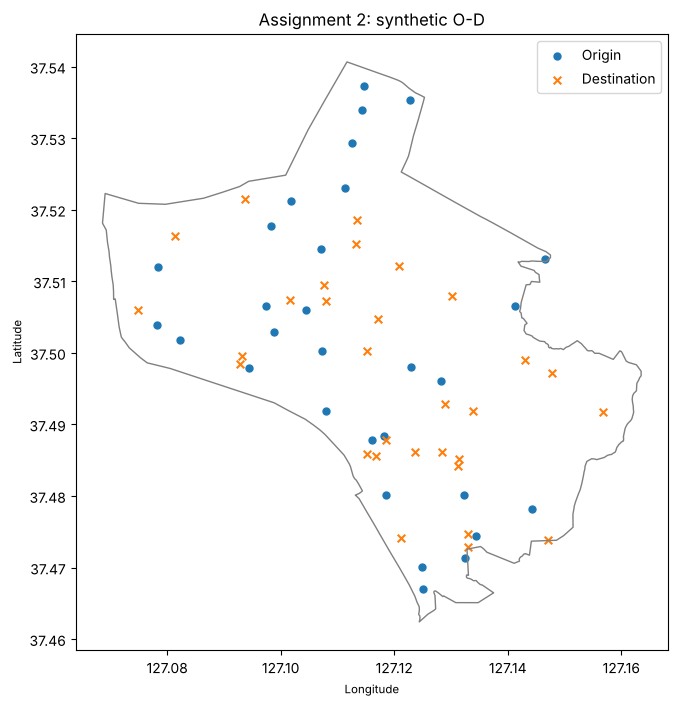

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

boundary = gpd.GeoDataFrame.from_features(load_boundary(DATA)["features"], crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(8, 8))
boundary.boundary.plot(ax=ax, color="gray", linewidth=1)
ax.scatter(od.origin_lon, od.origin_lat, label="Origin", s=25)
ax.scatter(od.destination_lon, od.destination_lat, label="Destination", marker="x", s=30)
ax.set(xlabel="Longitude", ylabel="Latitude", title="Assignment 2: synthetic O-D")
ax.legend()
fig.savefig(OUTPUT / "od_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 문제 1. 통행시간과 거리 비교 (60점)

### 1-1. 입력 자료 확인 (10점)

O-D 표의 인원과 출발시각을 확인하고, 스냅한 출발지와 목적지를 지도에 표시합니다.
다음 항목을 적습니다.

- O-D 행 수와 서로 다른 사람 식별자의 수
- 원래 좌표에서 스냅 좌표까지의 최대 거리
- GTFS 기준 운행일과 택시 속도 가정

지도 1장과 확인한 내용을 4~5줄로 정리합니다.

### 1-2. 경로 계산 (25점)

택시는 다익스트라로 가장 빨리 도착하는 도로 경로를 구합니다. 대중교통은 RAPTOR를 사용합니다.
먼저 한 사람의 경로를 구한 뒤, 같은 방법으로 30명의 경로를 계산합니다.

대중교통은 정류장에 도착한 뒤에도 목적지까지 걸어야 합니다.
도착 정류장 후보마다 마지막 도보시간을 더하고, 목적지에 가장 일찍 도착하는 경로를 고릅니다.
목적지 도착시각에서 오전 9시를 빼면 총 통행시간입니다. 이 값이 도보·대기·차내시간의 합과 같은지 확인합니다.

결과는 사람당 한 행으로 정리합니다. 시간은 분, 거리는 km로 표시합니다.
표에 넣을 항목은 다음과 같습니다.

- 사람 식별자와 수단별 경로 탐색 성공 여부
- 택시 통행시간과 이동거리
- 대중교통 총 통행시간, 도보시간, 대기시간, 차내시간, 환승 횟수
- 대중교통 총 이동거리, 차내 거리, 도보거리
- 시간 차이와 거리 차이: 대중교통 값에서 택시 값을 뺀 값

경로를 찾지 못한 경우에는 결측값과 실패 이유를 남깁니다.
평균을 구할 때는 택시와 대중교통 경로를 모두 찾은 사람만 포함합니다. 몇 명의 평균인지도 적습니다.

### 1-3. 결과 해석 (25점)

두 수단의 평균 통행시간과 평균 이동거리를 구합니다.
사람별 시간 차이와 거리 차이를 각각 막대그래프로 그립니다.
시간 차이가 가장 큰 사람 한 명을 골라, 아래 질문에 대한 답을 5~8문장으로 적습니다.

1. 두 수단의 통행시간과 거리는 각각 얼마입니까?
2. 대중교통의 도보·대기·차내시간은 각각 얼마입니까?
3. 거리 차이만으로 시간 차이를 설명할 수 있습니까?
4. 택시를 기다리는 시간이 생기거나 요금까지 비교한다면, 어느 수단이 낫다는 판단이 달라질까요? 그 이유는 무엇입니까?


### 제공 예제: 한 사람의 경로

`taxi_route`는 다익스트라를 호출하고, 선택한 도로 엣지의 길이와 통행시간을 합합니다.
속도는 모든 엣지에서 30km/h입니다. 도로 형상도 함께 반환합니다.

`transit_route`는 RAPTOR를 호출합니다. 마지막 정류장에서 목적지까지 걷는 시간을 더해
가장 일찍 목적지에 도착하는 경로를 고릅니다. 접근·도착 도보는 각각 800m, 환승 도보는 500m,
환승은 2회까지 허용합니다. 걷는 거리는 직선거리의 1.35배이고 보행속도는 1.2m/s입니다.

내부에서는 `smartmob.teaching.dijkstra.dijkstra`와 `smartmob.teaching.raptor.raptor`를 사용합니다.
과제에서는 아래 호출 방법을 그대로 사용해도 됩니다.

In [4]:
person = od.iloc[0]
taxi = taxi_route(graph, person.origin_node, person.destination_node)
public = transit_route(
    transit,
    (person.origin_lat, person.origin_lon),
    (person.destination_lat, person.destination_lon),
)
example = {"person_id": person.person_id, "taxi": taxi, "transit": public}
display(pd.DataFrame([
    {"mode": "taxi", "minutes": taxi["duration_min"], "km": taxi["distance_km"]},
    {"mode": "transit", "minutes": public["duration_min"], "km": public["distance_km"]},
]))

,mode,minutes,km
0,taxi,12.292462,6.146231
1,transit,32.983333,8.348681


`duration_min`은 총 통행시간(분), `distance_km`는 이동거리(km)입니다.
대중교통 결과에는 `walk_min`, `wait_min`, `in_vehicle_min`, `transfers`,
`walk_km`, `in_vehicle_km`, `routes`도 들어 있습니다.
`segments`는 지도 재생에 쓰는 구간별 시각·좌표이므로 그대로 보관합니다.

도보·대기·차내시간을 더하면 총 통행시간이 되는지 확인합니다.

In [5]:
parts = {k: public[k] for k in ("walk_min", "wait_min", "in_vehicle_min", "transfers", "routes")}
print(parts)
total = sum(public[k] for k in ("walk_min", "wait_min", "in_vehicle_min"))
print("시간 합:", total, "총 통행시간:", public["duration_min"])
assert abs(total - public["duration_min"]) < 1e-6

{'walk_min': 12.15, 'wait_min': 1.2333333333333334, 'in_vehicle_min': 19.6, 'transfers': 2, 'routes': ['30-3', '서울 8호선', '3315']}
시간 합: 32.983333333333334 총 통행시간: 32.983333333333334


### 답안 작성: 30명 비교

위의 한 사람 계산을 반복합니다. 결과 목록에는 각 사람의 `person_id`, `taxi`, `transit` 결과를 넣습니다.
경로를 찾지 못한 경우에는 실패 이유를 기록하고, 지표에는 결측값을 사용합니다.
`smartmob.assignment2.compare_person`을 사용하면 실패 기록까지 같은 형식으로 받을 수 있습니다.

1. `od`의 각 행에 대해 두 수단의 경로를 계산해 `results`에 모읍니다.
2. 결과에서 지표를 꺼내 사람당 한 행인 비교표를 만듭니다.
3. 대중교통 값에서 택시 값을 빼 시간·거리 차이를 계산합니다.
4. 두 수단 모두 성공한 사람들의 평균을 구하고 사람별 차이를 그래프로 그립니다.

아래 셀에 작성합니다. 비교표를 `comparison.csv`로 저장하고, 해석은 별도 Markdown 셀에 적습니다.

In [6]:
from smartmob.assignment2 import compare_person, results_table

results = [compare_person(graph, transit, row) for _, row in od.iterrows()]
print("계산한 인원:", len(results))
print("택시 성공:", sum(r["taxi"]["success"] for r in results),
      "/ 대중교통 성공:", sum(r["transit"]["success"] for r in results))

계산한 인원: 30
택시 성공: 30 / 대중교통 성공: 30


In [7]:
# 사람당 한 행 비교표 (시간: 분, 거리: km). 시간·거리 차이 = 대중교통 - 택시
comparison = results_table(results)
comparison.to_csv(OUTPUT / "comparison.csv", index=False, encoding="utf-8-sig")
print("행 수:", len(comparison))
display(comparison.round(2))

# 구성요소 합 = 총 통행시간 확인 (30명 전원)
ok_t = comparison[comparison.transit_success]
gap = (ok_t.transit_walk_min + ok_t.transit_wait_min + ok_t.transit_in_vehicle_min - ok_t.transit_duration_min).abs().max()
print("도보+대기+차내 - 총 통행시간 최대 오차(분):", gap)

행 수: 30


,person_id,taxi_success,taxi_reason,taxi_duration_min,taxi_distance_km,transit_success,transit_reason,transit_duration_min,transit_distance_km,transit_walk_min,transit_wait_min,transit_in_vehicle_min,transit_walk_km,transit_in_vehicle_km,transit_transfers,time_difference_min,distance_difference_km
0,P01,True,,12.29,6.15,True,,32.98,8.35,12.15,1.23,19.60,0.87,7.48,2,20.69,2.20
1,P02,True,,14.85,7.43,True,,41.07,8.89,14.53,4.43,22.10,1.04,7.84,2,26.22,1.46
2,P03,True,,13.30,6.65,True,,28.13,6.69,6.12,4.63,17.38,0.44,6.26,2,14.83,0.04
3,P04,True,,5.82,2.91,True,,21.92,4.91,5.52,4.37,12.03,0.40,4.51,1,16.10,2.00
4,P05,True,,5.03,2.51,True,,18.18,2.81,13.95,0.82,3.42,1.00,1.81,1,13.15,0.30
5,P06,True,,5.54,2.77,True,,22.87,4.56,12.68,3.85,6.33,0.91,3.65,2,17.33,1.80
6,P07,True,,7.53,3.76,True,,22.10,2.35,12.00,6.00,4.10,0.86,1.49,0,14.57,-1.41
7,P08,True,,9.20,4.60,True,,23.08,5.79,9.67,1.60,11.82,0.69,5.09,1,13.88,1.19
8,P09,True,,1.65,0.83,True,,12.60,2.24,8.13,1.65,2.82,0.58,1.66,1,10.95,1.41
9,P10,True,,4.64,2.32,True,,14.12,2.16,3.73,5.25,5.13,0.27,1.89,1,9.48,-0.16


도보+대기+차내 - 총 통행시간 최대 오차(분): 3.552713678800501e-15


In [8]:
# 1-1. 입력 자료 확인
print("O-D 행 수:", len(od), "/ 서로 다른 person_id:", od.person_id.nunique())
print("출발시각:", od.departure_time.unique().tolist(), "/ 운행일:", od.service_date.unique().tolist())
print("원래 좌표 -> 스냅 좌표 최대 거리(m): 출발", round(od.origin_snap_m.max(), 1),
      "/ 도착", round(od.destination_snap_m.max(), 1),
      "/ 전체", round(max(od.origin_snap_m.max(), od.destination_snap_m.max()), 1))

O-D 행 수: 30 / 서로 다른 person_id: 30
출발시각: ['09:00:00'] / 운행일: ['2024-10-07']
원래 좌표 -> 스냅 좌표 최대 거리(m): 출발 95.6 / 도착 92.5 / 전체 95.6


평균 대상: 30명


,택시,대중교통,차이(대중교통-택시)
평균 통행시간(분),8.06,24.05,15.99
평균 이동거리(km),4.03,5.03,1.00


,transit_walk_min,transit_wait_min,transit_in_vehicle_min
대중교통 평균(분),11.34,3.16,9.55


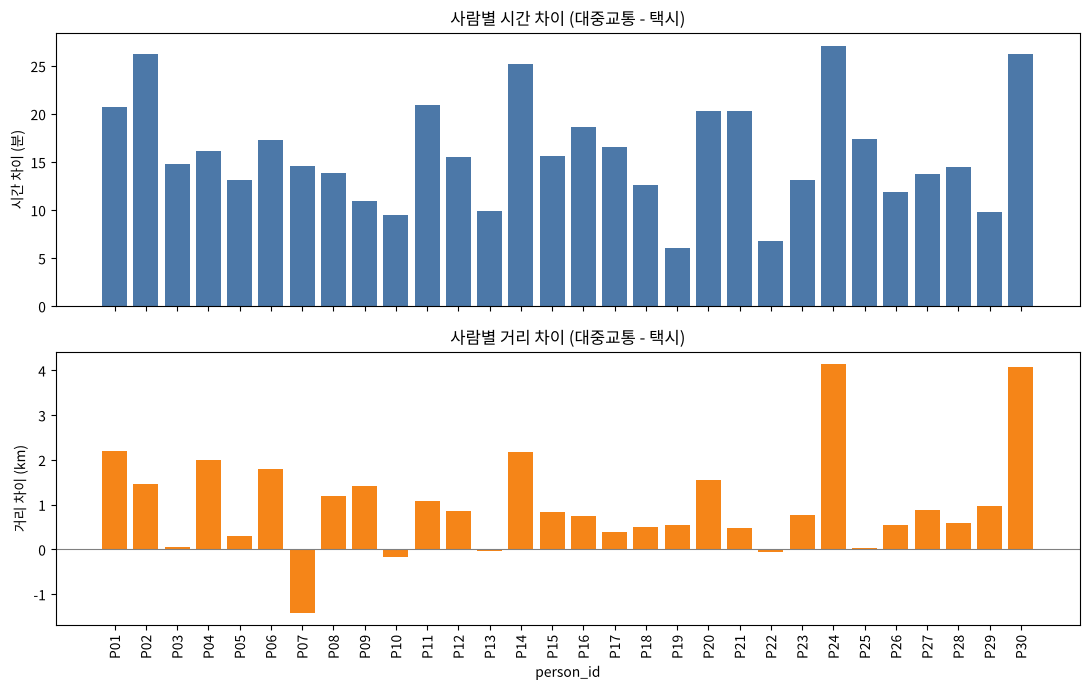

,값
person_id,P24
taxi_success,True
taxi_duration_min,3.157494
taxi_distance_km,1.578747
transit_success,True
transit_duration_min,30.233333
transit_distance_km,5.714126
transit_walk_min,13.316667
transit_wait_min,6.35
transit_in_vehicle_min,10.566667


거리 차이가 음수(대중교통 거리가 더 짧음)인 사람 수: 4
시간 차이가 양수(대중교통이 더 오래 걸림)인 사람 수: 30
시간 차이와 거리 차이의 상관계수: 0.67


In [9]:
# 1-3. 평균 (택시·대중교통 모두 성공한 사람만)
both = comparison[comparison.taxi_success & comparison.transit_success]
n = len(both)
summary = pd.DataFrame({
    "택시": [both.taxi_duration_min.mean(), both.taxi_distance_km.mean()],
    "대중교통": [both.transit_duration_min.mean(), both.transit_distance_km.mean()],
    "차이(대중교통-택시)": [both.time_difference_min.mean(), both.distance_difference_km.mean()],
}, index=["평균 통행시간(분)", "평균 이동거리(km)"]).round(2)
print(f"평균 대상: {n}명")
display(summary)
display(both[["transit_walk_min", "transit_wait_min", "transit_in_vehicle_min"]].mean().round(2).rename("대중교통 평균(분)").to_frame().T)

# 사람별 차이 막대그래프
import matplotlib
for name in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"):
    if any(name == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = name; break
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(both.person_id, both.time_difference_min, color="#4c78a8")
axes[0].set(ylabel="시간 차이 (분)", title="사람별 시간 차이 (대중교통 - 택시)")
axes[1].bar(both.person_id, both.distance_difference_km, color="#f58518")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set(ylabel="거리 차이 (km)", xlabel="person_id", title="사람별 거리 차이 (대중교통 - 택시)")
plt.setp(axes[1].get_xticklabels(), rotation=90)
fig.tight_layout()
fig.savefig(OUTPUT / "difference_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# 시간 차이가 가장 큰 사람
top = both.loc[both.time_difference_min.idxmax()]
display(top.drop(["taxi_reason", "transit_reason"]).to_frame("값"))
print("거리 차이가 음수(대중교통 거리가 더 짧음)인 사람 수:", int((both.distance_difference_km < 0).sum()))
print("시간 차이가 양수(대중교통이 더 오래 걸림)인 사람 수:", int((both.time_difference_min > 0).sum()))
print("시간 차이와 거리 차이의 상관계수:", round(both.time_difference_min.corr(both.distance_difference_km), 2))

### 해석과 답안

#### 1-1. 입력 자료 확인

- O-D 표는 30행이고 서로 다른 `person_id`도 30명이며, 출발시각은 모두 09:00:00입니다.
- 원래 좌표에서 스냅 좌표까지 옮긴 거리의 최대값은 출발지 95.6 m, 목적지 92.5 m입니다.
- GTFS 기준 운행일은 2024-10-07이고, 택시는 모든 도로에서 30 km/h 고정, 택시 대기 0분으로 계산했습니다.
- 스냅한 출발지·목적지 지도는 위의 `od_map.png`입니다. 두 수단 모두 30명 전원의 경로를 찾았습니다(`comparison.csv` 30행, 실패 0건).

#### 1-2. 경로 계산 결과 요약

택시·대중교통 경로를 모두 찾은 30명의 평균입니다(평균 대상 30명). 시간 차이와 거리 차이는 대중교통 값에서 택시 값을 뺀 값입니다.

| 항목 | 택시 | 대중교통 | 차이 |
|---|---:|---:|---:|
| 평균 통행시간 (분) | 8.06 | 24.05 | 15.99 |
| 평균 이동거리 (km) | 4.03 | 5.03 | 1.00 |

대중교통 평균 시간 구성은 도보 11.34분, 대기 3.16분, 차내 9.55분이며, 30명 모두 도보+대기+차내가 총 통행시간과 일치했습니다(최대 오차 약 4×10⁻¹⁵분).

#### 1-3. 결과 해석 (시간 차이가 가장 큰 사람: P24)

P24의 택시는 3.16분, 1.58 km이고 대중교통은 30.23분, 5.71 km로, 시간 차이 27.08분(30명 중 최대), 거리 차이 4.14 km입니다. 대중교통은 도보 13.32분, 대기 6.35분, 차내 10.57분으로 구성되고 환승은 2회(333 → 350 → 3315)입니다. 도보와 대기를 합한 19.67분이 총 통행시간의 약 65%를 차지합니다. 거리 차이만으로는 시간 차이를 설명하기 어렵습니다. 택시 속도 30 km/h로 4.14 km를 더 가는 데는 약 8.3분이 들 뿐이며, P24의 차이 27.08분에는 훨씬 못 미칩니다. 30명 중 4명은 대중교통 거리가 택시보다 짧았지만, 시간은 30명 전원이 대중교통이 더 오래 걸렸고 시간 차이와 거리 차이의 상관계수도 0.67에 그칩니다. 택시 대기가 생기면 판단이 달라질 수 있지만, 시간만 보면 평균 15.99분(P24는 27.08분)보다 길어져야 순서가 뒤집힙니다. 이번 계산은 택시 대기 0분, 속도 30 km/h 고정이고 요금은 계산하지 않았으므로, 요금까지 비교하면 판단이 달라질 수 있으나 이 결과만으로는 어느 쪽이 낫다고 말할 수 없습니다.


## 문제 2. 30명의 이동 시각화 (40점)

### 2-1. 이동 재생 (25점)

문제 1에서 구한 경로와 이동시각을 제공된 지도 재생 코드에 넣습니다.
왼쪽 지도에는 30명이 택시를 탄 경우를, 오른쪽에는 대중교통을 이용한 경우를 표시합니다.
두 지도는 같은 범위를 보여 주고, 같은 시각을 재생해야 합니다. 오전 9시에 시작해 마지막 사람이 도착할 때까지 재생합니다.

지도 위의 점 하나가 사람 한 명입니다. 두 지도에서 같은 사람을 찾을 수 있도록 같은 식별자를 붙입니다.
택시를 탄 사람의 점은 계산한 도로 경로를 구간별 통행시간에 맞춰 움직입니다.
대중교통을 이용하는 사람은 걷는 중, 기다리는 중, 차에 탄 상태, 도착한 상태를 구별해 표시합니다.
기다리는 동안에는 정류장에 머물고, 도착한 뒤에는 목적지에 남아 있습니다.
화면에는 현재 시각과 수단별 도착 인원수를 표시합니다.

버스·열차를 탄 동안에는 경유 정류장을 차례로 잇는 선 위에서 점이 움직입니다.
시간표의 출발·도착시각에 맞춰 정류장 사이 위치를 보간하고, 정차 중에는 점을 멈춥니다.
이 선은 실제 GPS 이동 기록이 아닙니다. 같은 차량에 탄 사람들의 점은 겹칠 수 있습니다.

두 지도를 함께 재생하는 HTML 파일 1개 또는 동영상 1개를 제출합니다.
재생 기능을 직접 구현할 필요는 없습니다.

### 2-2. 장면 비교 (15점)

오전 9시, 9시 10분, 9시 20분의 화면을 저장합니다.
해당 시각 전에 모두 도착했어도 화면을 저장합니다. 도착한 사람의 점은 목적지에 남겨 둡니다.
각 화면에는 두 지도와 수단별 도착 인원수가 보여야 합니다.

문제 1에서 고른 사람이 세 시각에 각각 어디에 있는지, 걷거나 기다리거나 차를 타고 있는지 비교합니다.
정류장에서 기다리는 동안에도 점이 움직인다면, 화면이 계산 결과를 어떻게 잘못 보여 주는지 설명합니다.
화면 3장과 설명 3~5문장을 노트북에 넣습니다.


### 제공 예제: 한 사람의 이동 재생

저장된 HTML을 브라우저에서 엽니다. 외부 지도 타일이나 인터넷 연결이 필요하지 않습니다.
두 지도에서 같은 번호의 점이 같은 사람입니다. 09:00·09:10·09:20 버튼으로 시각을 바꾸고,
사람 번호를 선택하면 두 수단의 경로와 현재 상태를 볼 수 있습니다.
`화면 PNG 저장`으로 현재 장면을 저장합니다.

In [10]:
preview = export_playback(
    graph, od.iloc[:1], [example], OUTPUT / "one_person.html"
)
print("재생 파일:", preview.relative_to(ROOT).as_posix())

재생 파일: outputs/assignment2_student/one_person.html


### 답안 작성: 30명 지도 재생

`results`를 완성하면 아래 셀에서 재생 파일을 만듭니다.
지도에서 저장한 장면 세 장과 과제의 질문에 대한 답을 제출 노트북에 넣습니다.

In [11]:
if len(results) == 30:
    playback = export_playback(graph, od, results, OUTPUT / "playback.html")
    print("저장:", playback)
else:
    print("30명 비교 셀에서 results를 먼저 작성합니다.")

저장: /home/claude/repo_dl/mobility-simulation-book/outputs/assignment2_student/playback.html


0900 | P24 · 택시: 탑승 / 대중교통: 도보


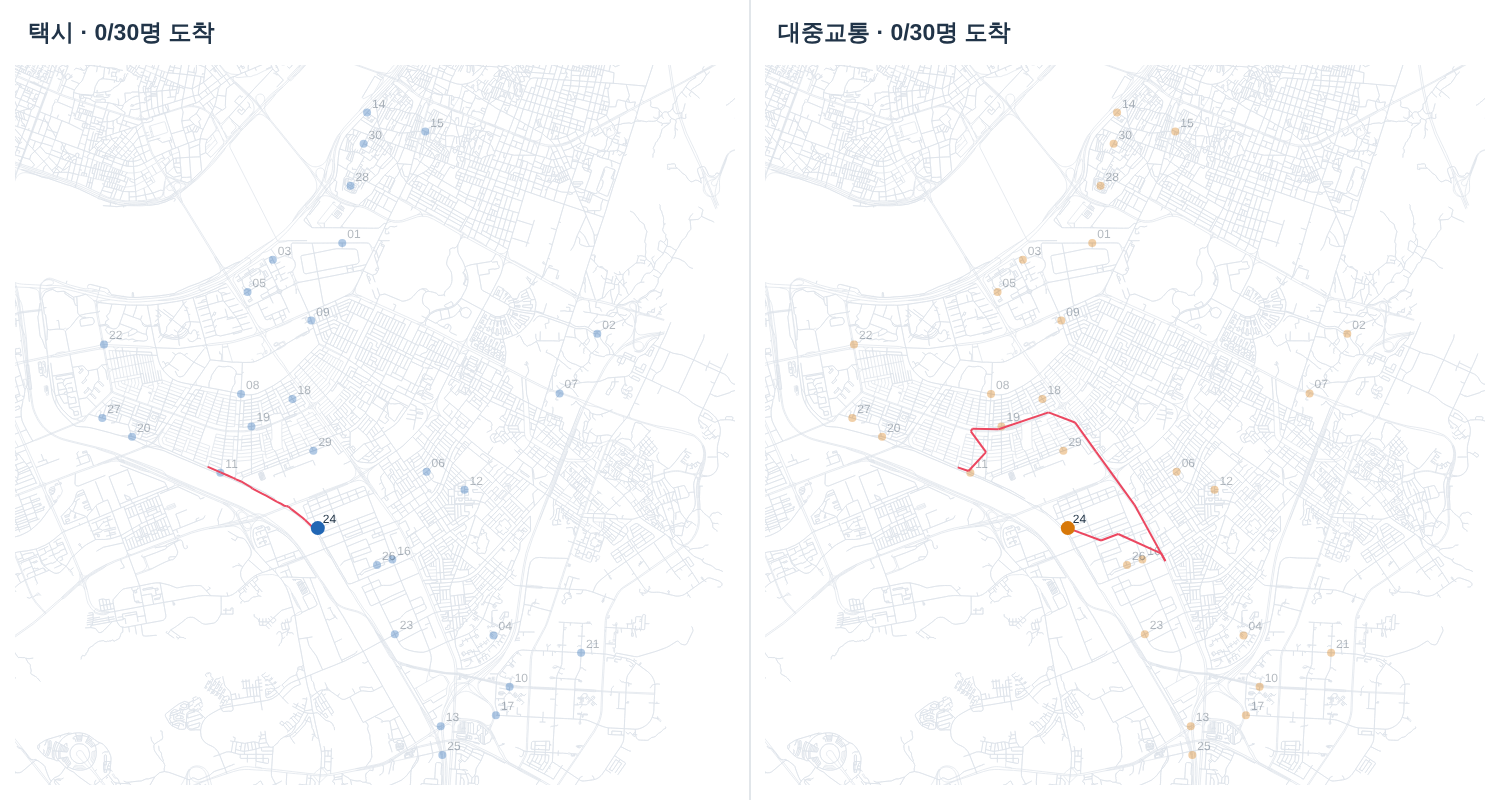

0910 | P24 · 택시: 도착 / 대중교통: 대기


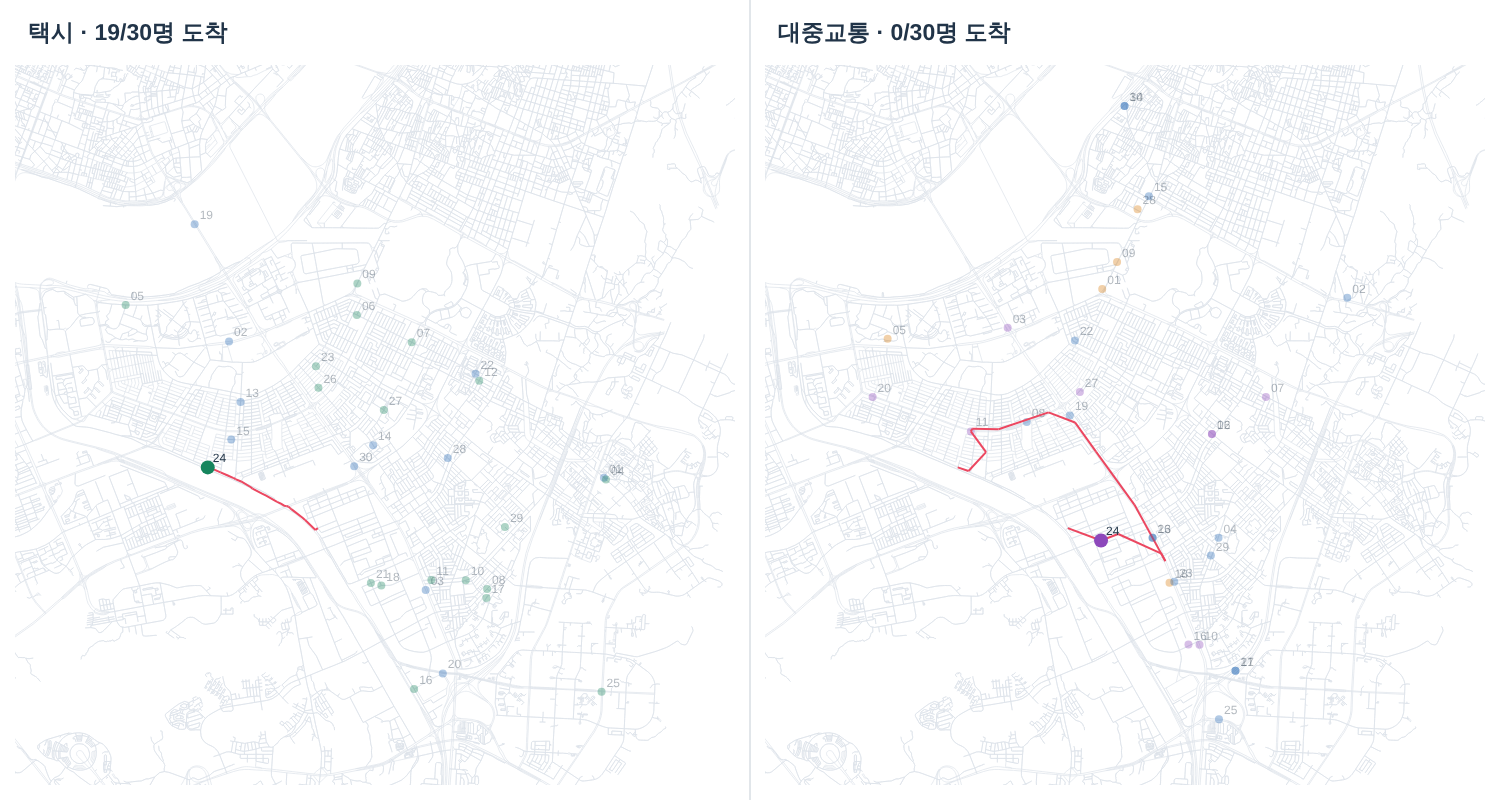

0920 | P24 · 택시: 도착 / 대중교통: 정차


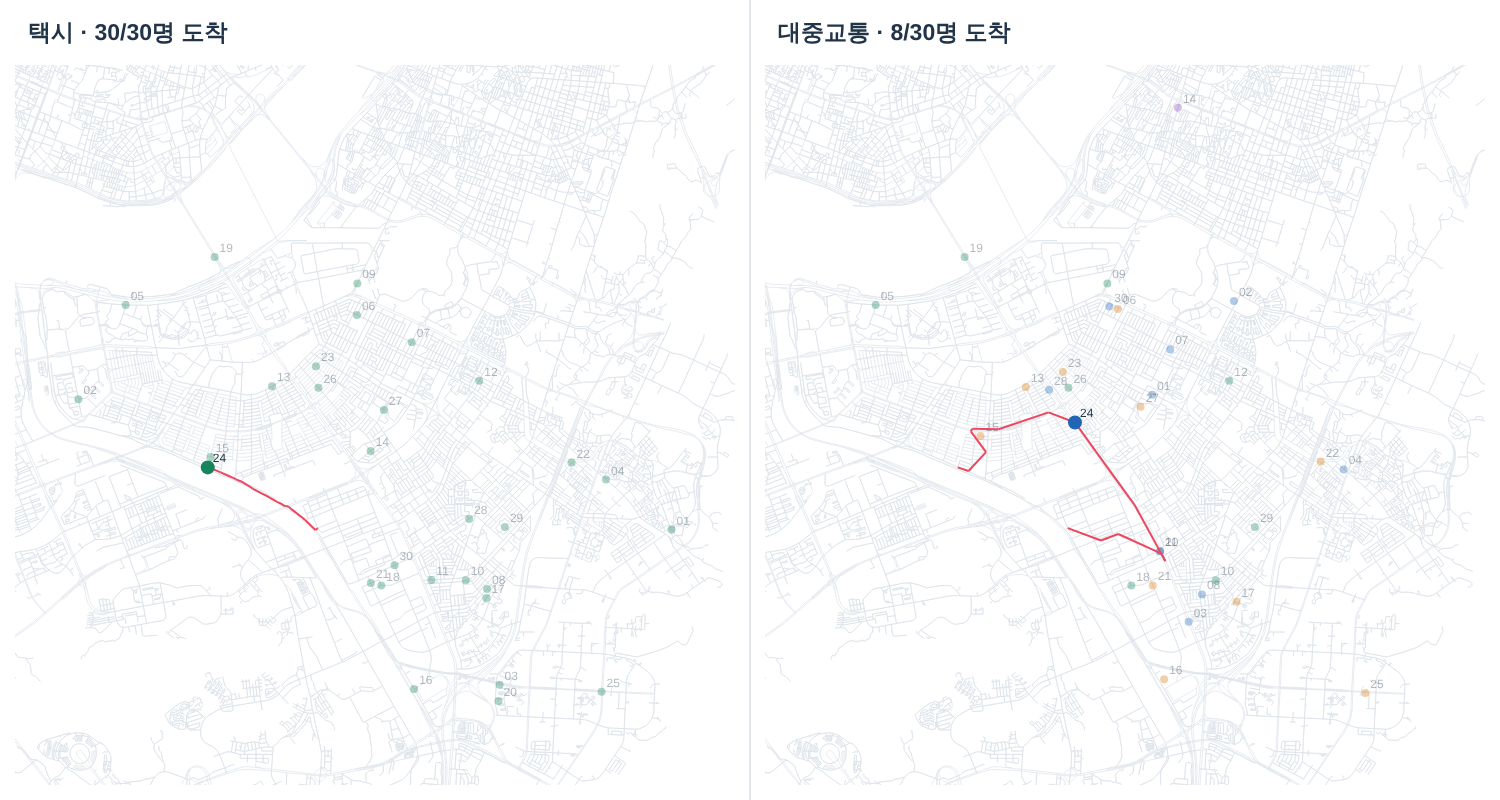

In [12]:
# 2-2. 09:00 / 09:10 / 09:20 장면 저장 (재생 HTML을 헤드리스 브라우저로 열어 캔버스를 PNG로 저장)
import base64, glob
from playwright.sync_api import sync_playwright
from IPython.display import Image

chrome = next(iter(glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome")), None)
focus = top.person_id   # 문제 1에서 고른 사람
def capture():
    shots = {}
    with sync_playwright() as p:
        browser = p.chromium.launch(**({"executable_path": chrome} if chrome else {}))
        page = browser.new_page(viewport={"width": 1600, "height": 1100})
        page.goto(playback.resolve().as_uri())
        page.select_option("#person", focus)
        for label, t in [("0900", 32400), ("0910", 33000), ("0920", 33600)]:
            page.click(f'[data-time="{t}"]')
            status = page.inner_text("#status")
            data = page.evaluate("document.querySelector('#map').toDataURL('image/png')")
            out = OUTPUT / f"scene_{label}.png"
            out.write_bytes(base64.b64decode(data.split(",", 1)[1]))
            shots[label] = (out, status)
        browser.close()
    return shots

# Jupyter 안에서는 동기 Playwright가 이벤트 루프와 충돌하므로 별도 스레드에서 실행합니다.
from concurrent.futures import ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=1) as pool:
    shots = pool.submit(capture).result()

for label, (path, status) in shots.items():
    print(label, "|", status)
    display(Image(filename=str(path)))

In [13]:
# 장면 비교 설명에 쓴 도착 인원·구간을 계산 결과로 다시 확인
t0 = 9 * 3600
for label, t in [("09:00", t0), ("09:10", t0 + 600), ("09:20", t0 + 1200)]:
    arrived = {m: sum(r[m]["arrival"] <= t for r in results) for m in ("taxi", "transit")}
    me = next(r for r in results if r["person_id"] == focus)
    state = {m: next((s["state"] for s in me[m]["segments"] if s["start"] <= t < s["end"]), "도착") for m in ("taxi", "transit")}
    print(label, "도착 인원", arrived, "|", focus, "상태", state)
print(focus, "택시 도착(분):", round((next(r for r in results if r['person_id']==focus)['taxi']['arrival'] - t0) / 60, 2),
      "/ 대중교통 도착(분):", round((next(r for r in results if r['person_id']==focus)['transit']['arrival'] - t0) / 60, 2))

09:00 도착 인원 {'taxi': 0, 'transit': 0} | P24 상태 {'taxi': '탑승', 'transit': '도보'}
09:10 도착 인원 {'taxi': 19, 'transit': 0} | P24 상태 {'taxi': '도착', 'transit': '대기'}
09:20 도착 인원 {'taxi': 30, 'transit': 8} | P24 상태 {'taxi': '도착', 'transit': '정차'}
P24 택시 도착(분): 3.16 / 대중교통 도착(분): 30.23


### 해석과 답안

#### 2-1. 이동 재생

30명의 택시·대중교통 이동을 `outputs/assignment2_student/playback.html` 한 파일에 담았습니다. 마지막 사람의 도착 시각은 택시 약 09:15(14.85분 후), 대중교통 약 09:41(41.07분 후)입니다.

#### 2-2. 장면 비교 (P24)

아래 세 장면은 위 셀에서 P24를 선택해 저장한 화면이고, 도착 인원과 P24의 상태는 계산 결과와 일치함을 확인했습니다.

| 시각 | 도착 인원 (택시 / 대중교통) | P24 택시 | P24 대중교통 |
|---|---|---|---|
| 09:00 | 0명 / 0명 | 출발지에서 탑승 시작 | 첫 정류장으로 도보 중 |
| 09:10 | 19명 / 0명 | 3.16분에 도착해 목적지에 머묾 | 첫 정류장에서 대기 중 (8.12~11.60분 구간) |
| 09:20 | 30명 / 8명 | 목적지에 머묾 | 두 번째 노선(350) 탑승 중, 정류장 정차 구간(19.92~20.08분) |

P24는 택시로는 09:00 직후 이미 목적지에 도착하지만, 대중교통으로는 09:10에도 아직 첫 정류장에서 버스를 기다리고 09:20에야 두 번째 버스에 타고 있습니다. 만약 정류장에서 기다리는 동안에도 점이 움직인다면, 화면은 사람이 이동하는 것처럼 보여 계산 결과의 대기시간(P24는 총 6.35분)을 이동시간으로 잘못 보여 줍니다. 그러면 대기·도보·차내시간의 구성도 알아볼 수 없고, 점의 위치가 시간표와 어긋나 실제로는 서 있는 사람이 먼저 도착한 것처럼 보일 수 있습니다.


## 제출물과 채점 기준

다음 세 파일을 제출합니다.

- 실행 결과와 답안을 작성한 노트북: 지도, 그래프, 재생 화면 3장 포함
- 사람별 비교 결과 CSV: 30행
- 이동 시각화 HTML 또는 동영상

| 항목 | 채점 내용 | 배점 |
|---|---|---:|
| 입력 자료 | 인원·출발시각·스냅 거리·운행일 확인 | 10 |
| 경로 계산 | 목적지까지의 시간·거리와 시간 구성요소 | 25 |
| 결과 해석 | 평균, 사람별 차이, 차이가 생긴 이유 | 25 |
| 이동 재생 | 경로·이동시각·대기·도착 상태의 일치 | 25 |
| 장면 비교 | 지정 시각의 도착 인원과 선택한 사람의 상태 | 15 |

화면 디자인은 채점하지 않습니다.

추가 분석은 선택 사항이며 채점에 포함하지 않습니다.
한 사람의 환승 상한을 0회와 2회로 바꾸어 경로를 비교하거나, 7장의 요금 계산·수단 선택 모형을 적용해 볼 수 있습니다.

## 참고 실습

- [3장 다익스트라](https://github.com/jihoyeo/mobility-simulation-book/blob/main/labs/ch03_dijkstra.ipynb)
- [4장 속도와 통행시간](https://github.com/jihoyeo/mobility-simulation-book/blob/main/labs/ch04_speeds_engine.ipynb)
- [5장 GTFS](https://github.com/jihoyeo/mobility-simulation-book/blob/main/labs/ch05_gtfs.ipynb)
- [6장 RAPTOR](https://github.com/jihoyeo/mobility-simulation-book/blob/main/labs/ch06_raptor.ipynb)
- [7장 환승·요금과 수단 선택](https://github.com/jihoyeo/mobility-simulation-book/blob/main/labs/ch07_raptor_fare.ipynb)
